In [5]:
import sys
import os
sys.path.append('..')

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import hann
from scipy.ndimage import gaussian_filter1d


(np.float64(-0.5), np.float64(5999.5), np.float64(4504.5), np.float64(-0.5))

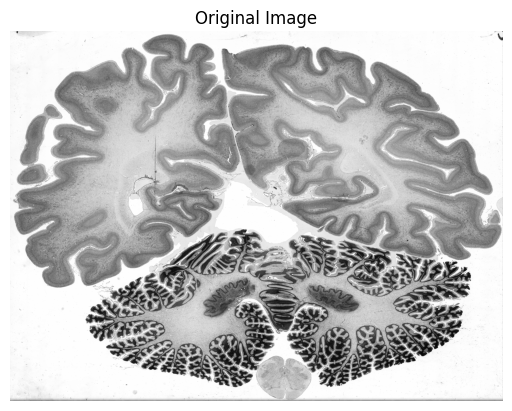

In [6]:
ori = Image.open('data/patch_samples/heatmaps/original.png').convert('L')
plt.imshow(ori, cmap='gray')
plt.title("Original Image")
plt.axis("off")

In [7]:
def radial_profile(power):
    h, w = power.shape
    cy, cx = h//2, w//2

    y, x = np.indices((h, w))
    r = np.sqrt((x-cx)**2 + (y-cy)**2)

    r_int = r.astype(int)

    tbin = np.bincount(r_int.ravel(), power.ravel())
    nr = np.bincount(r_int.ravel())

    radial = tbin / np.maximum(nr, 1)

    r_vals = np.arange(len(radial))

    # correct normalization
    r_norm = r_vals / r.max()

    return r_norm, radial

In [10]:
def effective_resolution_cutoff(patch,
                                detrend_sigma=12,
                                r_min_frac=0.05,
                                tail_frac=0.85):

    patch = patch.astype(np.float32)

    # --- detrend (remove low-frequency background)
    background = gaussian_filter(patch, detrend_sigma)
    g = patch - background

    # --- apply 2D Hann window
    wy = hann(patch.shape[0])
    wx = hann(patch.shape[1])
    window = np.outer(wy, wx)
    g *= window

    # --- FFT power spectrum
    F = np.fft.fftshift(np.fft.fft2(g))
    P = np.abs(F)**2

    # --- radial mean spectrum
    r, prof = radial_profile(P)
    n = len(prof)

    # --- estimate noise floor from tail
    tail_start = int(tail_frac * n)
    N0 = np.median(prof[tail_start:])

    # corrected spectrum
    prof_corr = np.maximum(prof - N0, 0)

    # smooth
    prof_corr = gaussian_filter1d(prof_corr, 2)

    # ignore center
    start = int(r_min_frac * n)

    # relative threshold
    threshold = 0.05 * prof_corr[start:].max()

    idx = np.where(prof_corr > threshold)[0]
    idx = idx[idx >= start]

    if len(idx) == 0:
        fc = 0
    else:
        fc = r[idx.max()]

    return fc, r, prof, prof_corr

In [12]:
base = 'data/patch_samples'
for i in ["spatial_high", "spatial_low", "spectral_high", "spectral_low"]:
    path = os.path.join(base, i)

    fc_values = []

    for fname in os.listdir(path):
        if fname.endswith(".png"):
            img_path = os.path.join(path, fname)

            patch = Image.open(img_path).convert('L')
            patch = np.array(patch)

            fc, r, prof, prof_corr = effective_resolution_cutoff(patch)
            fc_values.append(fc)

    avg_fc = np.mean(fc_values)

    print(f"{i}: avg cutoff frequency = {avg_fc:.4f}  (N={len(fc_values)})")

spatial_high: avg cutoff frequency = 0.2088  (N=100)
spatial_low: avg cutoff frequency = 0.3433  (N=100)
spectral_high: avg cutoff frequency = 0.4290  (N=100)
spectral_low: avg cutoff frequency = 0.1141  (N=100)


effective cutoff frequency: 0.35355339059327373


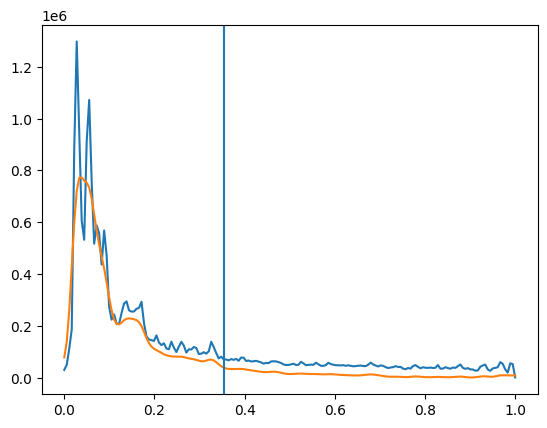

In [6]:
patch = Image.open('data/patch_samples/spectral_high/patch_0291460_r52736_c72576.png').convert('L')
patch = np.array(patch)
fc, r, prof, prof_corr = effective_resolution_cutoff(patch)

print("effective cutoff frequency:", fc)

plt.plot(r, prof)
plt.plot(r, prof_corr)
plt.axvline(fc)

In [13]:
import cv2
from scipy import ndimage
import numpy as np
import os
from PIL import Image

def laplacian_variance(img):
    lap = cv2.Laplacian(img, cv2.CV_64F)
    return lap.var()

def sobel_energy(img):
    gx = ndimage.sobel(img, axis=1)
    gy = ndimage.sobel(img, axis=0)
    return np.mean(gx**2 + gy**2)

In [14]:
base = "data/patch_samples"

groups = ["spatial_high","spatial_low","spectral_high","spectral_low"]

results = {}

for g in groups:
    
    path = os.path.join(base, g)
    
    fc_values = []
    lap_values = []
    sobel_values = []
    
    for fname in os.listdir(path):
        if fname.endswith(".png"):
            
            img_path = os.path.join(path, fname)
            
            patch = Image.open(img_path).convert("L")
            patch = np.array(patch)
            
            fc, _, _, _ = effective_resolution_cutoff(patch)
            
            fc_values.append(fc)
            lap_values.append(laplacian_variance(patch))
            sobel_values.append(sobel_energy(patch))
    
    results[g] = {
        "fc": np.array(fc_values),
        "lap": np.array(lap_values),
        "sobel": np.array(sobel_values)
    }

    print(f"\n{g}")
    print("cutoff:", np.mean(fc_values))
    print("laplacian:", np.mean(lap_values))
    print("sobel:", np.mean(sobel_values))


spatial_high
cutoff: 0.2088174713191523
laplacian: 2200.3357861437275
sobel: 120.7127783203125

spatial_low
cutoff: 0.34333348789643703
laplacian: 31.54647055779584
sobel: 37.128054809570315

spectral_high
cutoff: 0.4289596996807454
laplacian: 130.26210829891264
sobel: 77.13380859375

spectral_low
cutoff: 0.11407621118361096
laplacian: 180.3829542556242
sobel: 97.7169110107422


In [15]:
fc_all = []
lap_all = []
sobel_all = []

for g in groups:
    fc_all.extend(results[g]["fc"])
    lap_all.extend(results[g]["lap"])
    sobel_all.extend(results[g]["sobel"])

fc_all = np.array(fc_all)
lap_all = np.array(lap_all)
sobel_all = np.array(sobel_all)

corr_lap = np.corrcoef(fc_all, lap_all)[0,1]
corr_sobel = np.corrcoef(fc_all, sobel_all)[0,1]

print("\nCorrelation with cutoff frequency")
print("Laplacian:", corr_lap)
print("Sobel:", corr_sobel)


Correlation with cutoff frequency
Laplacian: -0.20151700364231634
Sobel: -0.37297604466504314


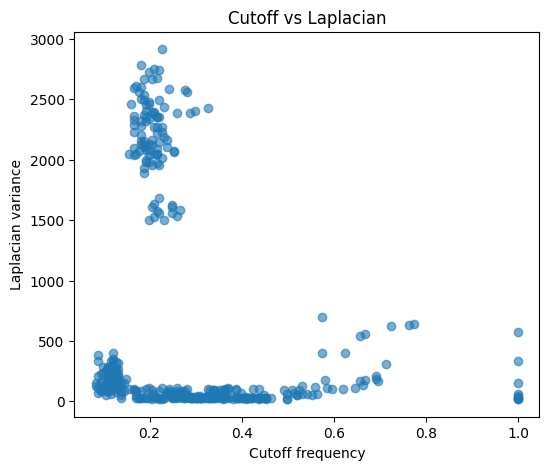

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(fc_all, lap_all, alpha=0.6)
plt.xlabel("Cutoff frequency")
plt.ylabel("Laplacian variance")
plt.title("Cutoff vs Laplacian")
plt.show()